# **Modelling Notebook**
---
*finally, the interesting part!*

**Here I will:**
*Part A: setup, two trained models, one confusion matrix*
1. split data: `train_test_split(test_size=0.2, random_state=42)`
2. train a Logistic Regression first since this is my baseline
3. print the classification_report and note precision, recall, F1 for the churn class specifically
4. plot and save the confusion matrix
4. train a Random Forest, compare the two

*Significant progress checkpoint: two trained models, one confusion matrix saved, and I can explain in one sentence why recall matters more than precision for churn.*

---

*Part B: building the thing that makes this project different from every tutorial.*
1. Train XGBoost, compare all three models in a summary table (accuracy, precision, recall, F1).
2. Plot feature importance from XGBoost and save as feature_importance.png
3. Picking the best model!!
4. Summary

### **Imports and loading cleaned data**

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.metrics import roc_auc_score, RocCurveDisplay
from sklearn.metrics import precision_recall_fscore_support

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/telco_churn_cleaned.csv')
df.shape

(7043, 31)

### **Separating the features from target**

In [9]:
# splitting the df into features and target I'm trying to predict
X = df.drop(columns=['Churn'])
y = df['Churn']

print(X.shape) # returns (rows, columns) to see our dataset at a glance
print("-" * 20)
print(y.value_counts()) # counts the frequency of unique values within the df

# we can see the output column no. for X is now 30 since we dropped the Churn col.

(7043, 30)
--------------------
Churn
0    5174
1    1869
Name: count, dtype: int64


### **Splitting the dataset:  train/test split**

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
) # stratify=y makes sure my splits have the same churn ratio so the test isn't all non-churners

print(f"Training rows: {X_train.shape[0]}") # 80% = 5634 rows
print(f"Testing rows: {X_test.shape[0]}") # 20% = 1409 rows

Training rows: 5634
Testing rows: 1409


**Note:**
- I am not saving this train/test CSVs or creating a separate validation set for a project at this scale because I'm using `random_state=42`
- This means that I am regenerating the data from the same cleaned CSV every time and the seed makes it identical every single run. So saving it separately adds no value and just duplicates data in my repo.
- *However,* if I did have millions of rows and this was a production ML system maybe with a team of engineers, that would become necessary.
- For now, the `random_state=42` is my guarantee of reproducibility.
- Regarding the lack of a validation set, I only have about 7000 rows and splitting 3 ways shrinks each set significantly. Plus, I am not doing serious hyperparameter tuning. What *I AM* doing is comparing 3 off-the-shelf models with default settings, which doesn't need a validation set.

### **Training Logistic Regression (LR) Model (my baseline model)**
---
*Logistic Regression draws a mathematical boundary between states: 'likely to churn' and 'likely to stay'.*
- Outputs a probability for each customer (each row) where: above 50% = predicted churner.

**my focus is on the rows labelled 1 (as they are churners)**

Lastly, the `recall` tells me that *of all the customers who actually churned, what percentage did my model catch?*

In [11]:
lr = LogisticRegression(max_iter=1000, random_state=42)
# max_iter=1000 gives enough cycles to find our boundary

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
print("--------- Logistic Regression ----------")
print(classification_report(y_test, y_pred_lr)) # shows us the precision, recall, and F1 for both classes

--------- Logistic Regression ----------
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



#### *Observation and Insights:*
- The baseline model performs reasonably well overall, with 81% accuracy across 1,409 test customers. 
- For the churn class specifically (label 1), precision of 0.66 means that when the model flags a customer as likely to churn, it is correct
66% of the time. 
- Recall of 0.56 means it successfully identified 56% of customers
who actually churned, missing the remaining 44%.


- The model is strong at identifying customers who will stay (recall 0.89 for label 0) but *weaker at catching churners*, which is the more costly error for the business.
- This sets the benchmark all subsequent models must beat on recall.

#### *Plotting the LR Confusion Matrix*

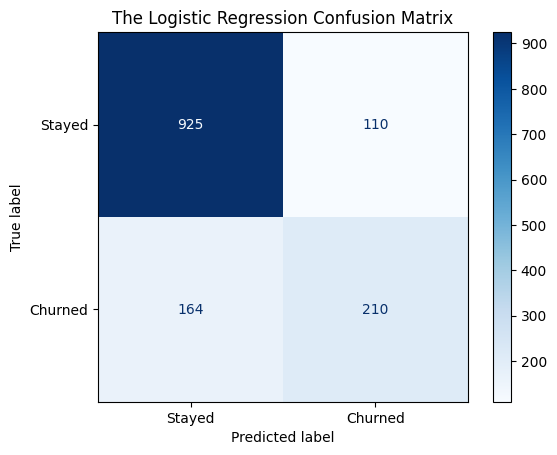

In [12]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Stayed', 'Churned'])

disp.plot(cmap='Blues')
plt.title('The Logistic Regression Confusion Matrix')

plt.savefig('../outputs/confusion_matrix_lr.png', bbox_inches='tight')
plt.show()

##### *Observation and Insights:*
The matrix shows 4 outcomes:
- Customers correctly identified as staying: top-left (925)
- Customers correctly identified as churning: bottom right (210)
- Customers wrongly flaggged as churning (FALSE ALARMS): top-right (110)
- Customers who churned but were missed (COSTLY ONES): bottom-right (164)

**What the Axes Mean:**
- x-axis (Predicted Label) - *what the model guessed*
- y-axis (True Label) - *what actually happened in real life*

*The number we want to minimise is the missed churners (bottom-left cell) which currently shows 164*

The Logistic Regression caught 210 out of 374 real churners. This is right as it about 56%, matching the recall (0.56) from the classification report. But this also means, it missed nearly half of the churners.

**Next, I will train the Random Forest and XGBoost models to try to push that 164 value (gap) down.**

---

### **Feature Importance from LR Coefficients**
---
*A positive coefficient means the feature pushes toward churn, a negative one pushes away from churn. So we get both direction and magnitude.* 

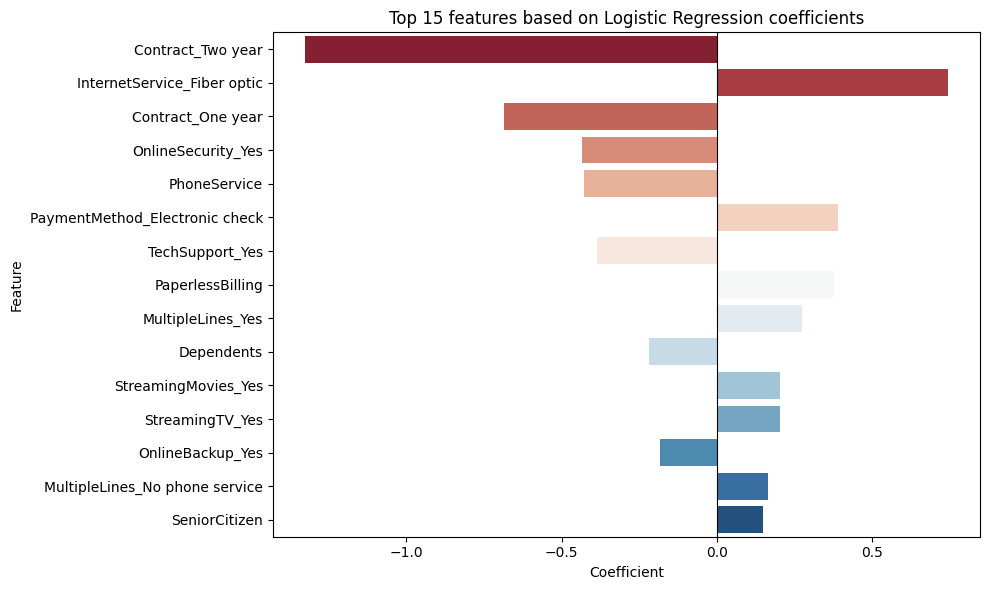

In [13]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_[0]
})

coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index)
coef_df = coef_df.head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='RdBu')
plt.title('Top 15 features based on Logistic Regression coefficients')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('../outputs/lr_coefficients.png', bbox_inches='tight')
plt.show()

#### *Observation and Insights:*
**Negative Coefficients (these push towards STAYING):**
- Contract_Two year is the strongest signal in the entire model by far. Having a **two-year contract dramatically reduces churn probability.**
- Contract_One year does the same but weaker. 
- OnlineSecurity_Yes and TechSupport_Yes also reduce churn meaning **customers who feel protected and supported stay longer.**

**Positive Coefficients (these push toward CHURNING):**
- InternetService_Fiber optic is the biggest churn driver meaning **customers on fiber optic are significantly more likely to leave.**
- PaymentMethod_Electronic check, PaperlessBilling, and SeniorCitizen all push toward churn as well.

---
- **Customers most at risk** are fiber optic users, on month-to-month contracts, paying by electronic check, with no online security or tech support add-ons. 
- **Customers most likely to stay** are locked into long contracts with protection services. Retention strategy practically writes itself from this chart.

### **Training Random Forest (RF) Model**
---
*Random Forest will build 100 decision trees (n_estimators=100) with each being trained on a random slice of the data and features. The final prediction is a majority vote across all 100 trees.*

**It's more powerful than LR because it captures *non-linear patterns* like customers on month-to-month contracts who ALSO have high monthly charges AND  have called support more than twice are very likey to churn.**

In [14]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("------------------ Random Forest ------------------")
print(classification_report(y_test, y_pred_rf))

------------------ Random Forest ------------------
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.48      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409



#### *Observation and Insights:*
- Random Forest **underperforms the baseline across every metric.** 
- Accuracy drops to 78%, and churn recall falls to 0.48, meaning it **missed over half of all real churners in the test set.**
- Despite being a more complex model, the additional complexity does not translate to better performance here.
---
Maybe Random Forest may be overfitting slightly to the training data or
struggling with the class imbalance. It is eliminated as a candidate model.

### **Feature Importance for RF**
---

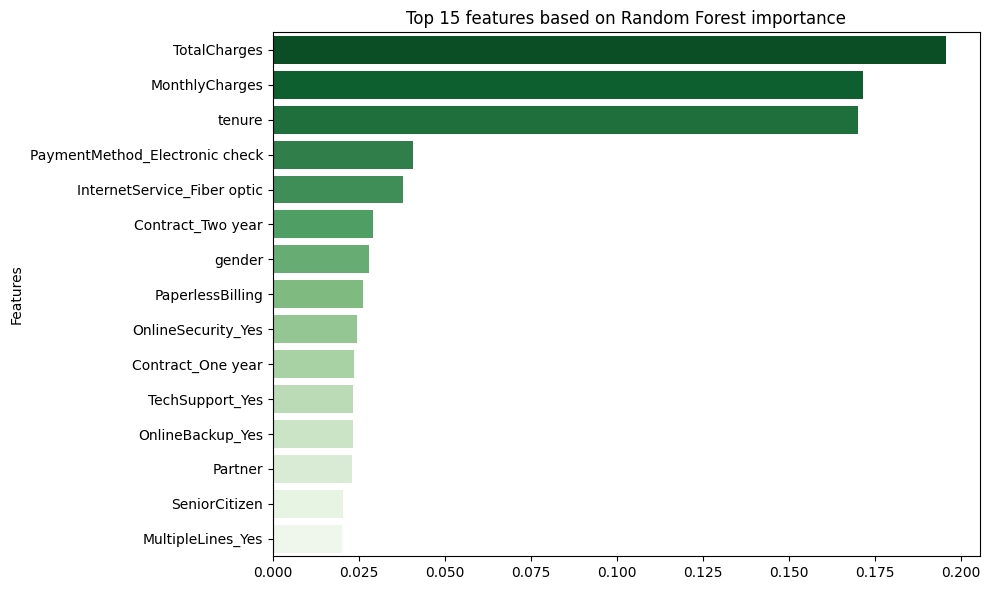

In [15]:
rf_importances = pd.Series(rf.feature_importances_, index=X.columns)
rf_importances = rf_importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=rf_importances.values, y=rf_importances.index, palette='Greens_r')

plt.ylabel('Features')
plt.title('Top 15 features based on Random Forest importance')
plt.tight_layout()
plt.savefig('../outputs/rf_importance.png', bbox_inches='tight')
plt.show()

#### *Observation and Insights:*
- What we see is strikingly different from the other two and worth paying attention to.
- `TotalCharges`, `MonthlyCharges`, and `tenure` dominate completely — all three are continuous numeric variables. Everything else barely registers.
    - This means RF probably latched onto the financial and time-based variables almost exclusively, largely ignoring contract type and internet service which the other two models flagged as critical.

---
This is actually a red flag for Random Forest as **it's over-relying on correlated variables** because TotalCharges is literally just MonthlyCharges multiplied by tenure, so these three are not independent signals. 

The model is essentially counting the same thing three times. This likely explains why it underperformed. It found a pattern that looked strong in training but wasn't as predictive on unseen data.

### **Training XGBoost**
---
*XGBoost also builds trees, but in a different way: each new tree specifically corrects the mistakes the previous tree made. Pretty cool because it means it's **sequential learning** rather than parallel voting*

In [16]:
xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1, # controls how aggressively each tre should correct errors (lower: more careful with less overfitting)
    max_depth=4, # (limits how complex each tree can get)
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
print("------------------ XGBoost ------------------")
print(classification_report(y_test, y_pred_xgb))

------------------ XGBoost ------------------
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



#### *Observation and Insights:*
- XGBoost sits between the two previous models. 
- Accuracy of 80% is close to LR, and precision on the churn class matches it at 0.66.
- However, churn recall of 0.52 falls short of LR's 0.56,
meaning it catches fewer at-risk customers despite being a more complex model.
---
**XGBoost's value in this project lies less in its classification report and more in its feature importance output, which provides interpretable, business-relevant insight into the drivers of churn, something Logistic Regression cannot offer as cleanly.**

### **Comparing All Three Models**
---
*Putting all our models side by side to compare them honestly.*

**Focus is not just on accuracy but also on recall and F1 for the churn class.**

In [17]:
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

# loading all the models
models = {
    'Logistic Regression': y_pred_lr,
    'Random Forest': y_pred_rf,
    'XGBoost': y_pred_xgb
}

# storing all the scores for each model
results = []
for name, preds in models.items():
    results.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, preds), 3),
        'Precision': round(precision_score(y_test, preds), 3),
        'Recall': round(recall_score(y_test, preds), 3),
        'F1 Score': round(f1_score(y_test, preds), 3)
    })

# making a df of the results list and displaying them
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

              Model  Accuracy  Precision  Recall  F1 Score
Logistic Regression     0.806      0.656   0.561     0.605
      Random Forest     0.784      0.621   0.481     0.542
            XGBoost     0.801      0.656   0.524     0.582


#### *Observation and Insights:*
From the comparison, we see that **Logistic Regression caught 56% of real churners, Random Forest caught only 48%, XGBoost caught 52%.** 

- LR wins with regards to recall, which is the metric that matters most for churn. Interesting. It identified the highest proportion of at-risk customers.
- All three are missing roughly half of real churners. This is a dataset limitation.

---
**All three models show moderate recall**, reflecting the inherent difficulty of predicting churn from behavioural features alone. A recall of 0.56 means the model identifies just over half of at-risk customers, enough to drive meaningful retention value, but with acknowledged room for improvement with richer data (e.g. customer support call logs, NPS scores, usage frequency).

### **ROC-AUC scores and ROC curve**
---
*Accuracy and recall only tell us how the model performs at one threshold (50%). So ROC-AUC measures performance across ALL possible thresholds.*

ROC-AUC Scores:
Logistic Regression: 0.843
Random Forest:       0.823
XGBoost:             0.844


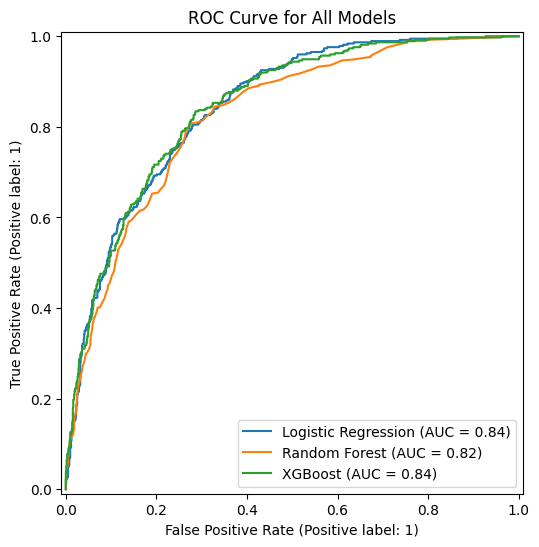

In [18]:
print("ROC-AUC Scores:")
print(f"Logistic Regression: {roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]):.3f}")
print(f"Random Forest:       {roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]):.3f}")
print(f"XGBoost:             {roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1]):.3f}")

fig, ax = plt.subplots(figsize=(8, 6))

for model, name in [(lr, 'Logistic Regression'), (rf, 'Random Forest'), (xgb, 'XGBoost')]:
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)

plt.title('ROC Curve for All Models')
plt.savefig('../outputs/roc_curve.png', bbox_inches='tight')
plt.show()

#### *Observation and Insights:*
Woahh that's interesting. The classification report said LR wins, but the ROC curve says LR and XGBoost are tied at AUC = 0.84, with Random Forest slightly behind at 0.82.

- AUC of 0.84 means the model correctly ranks a random churner above a random non-churner 84% of the time which is genuinely solid for this dataset. 
- The gap between 0.84 and 0.82 is small but consistent.

---
- The key nuance is that the ROC curve measures performance across all possible decision thresholds, not just 50%. 
- The fact that XGBoost ties LR here but loses on recall suggests *XGBoost's probability estimates are well-calibrated* — it's competitive overall, **it just makes different tradeoffs at the default 50% cutoff.** 

I think potentially tuning XGBoost's threshold below 50% will do well to catch more churners and close the recall gap.

### **Precision-Recall curve**
---
*More informative than ROC when dealing with our imbalanced classes (73% stayed, 27% churned).*

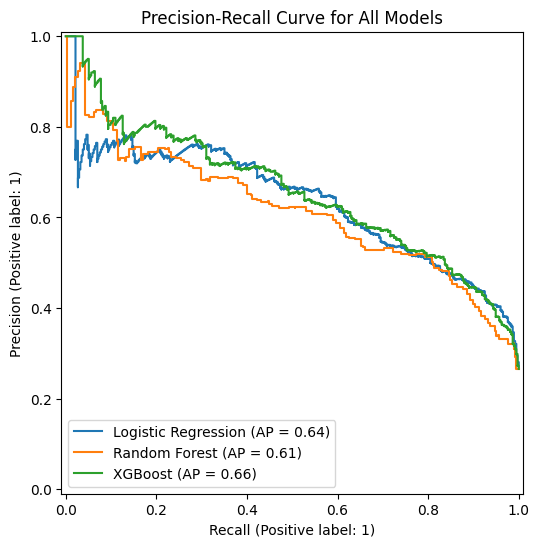

In [19]:
fig, ax = plt.subplots(figsize=(8, 6))
for model, name in [(lr, 'Logistic Regression'), (rf, 'Random Forest'), (xgb, 'XGBoost')]:
    PrecisionRecallDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)


plt.title('Precision-Recall Curve for All Models')
plt.savefig('../outputs/precision_recall_curve.png', bbox_inches='tight')
plt.show()

#### *Observation and Insights:*
- XGBoost wins here with AP = 0.66, versus LR at 0.64 and RF at 0.61.
- Average Precision summarises the area under this curve where **higher means the model maintains better precision as you push recall higher.**
- XGBoost's curve stays above LR's across most of the recall range, meaning *if we lower the decision threshold to catch more churners, XGBoost degrades more gracefully* because it doesn't sacrifice precision as fast.
- **Random Forest's curve drops off earliest, confirming it's the weakest of the three.**

### **Feature Importance from XGBoost**
---
*Here, we're going to look at the features the XGBoost model relied on the most when making decisions.*

**This chart wil show us *WHY* customers churn, *NOT JUST WHO* will churn.**

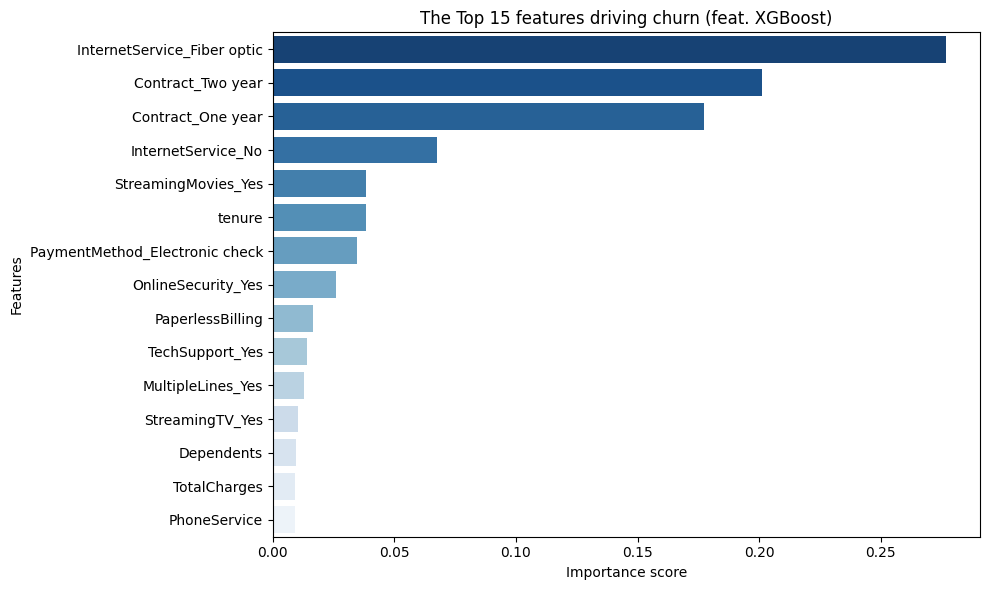

In [20]:
importances = pd.Series(xgb.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, palette='Blues_r')
plt.title('The Top 15 features driving churn (feat. XGBoost)')
plt.xlabel('Importance score')
plt.ylabel('Features')
plt.tight_layout()
plt.savefig('../outputs/feature_importance.png', bbox_inches='tight')
plt.show()

#### *Observation and Insight:*
- *InternetService_Fiber optic (0.28)* is by far the biggest driver. **Fiber optic customers churn the most.**
    - They're likely paying premium prices and have more alternatives available or higher expectations that aren't being met.
- *Contract_Two year (0.20) and Contract_One year (0.18):* these being high importance means contract type is a massive churn signal. 
    - But we also see that **having a long contract reduces churn**. 
    - Customers on month-to-month (the baseline, dropped during encoding) are the **most at risk**. The model is saying **"two-year contract = strong signal someone will stay."**
- *InternetService_No (0.07):* customers with **no internet service churn less.** Makes sense since they're likely basic phone-only customers with fewer reasons to leave.
- *tenure (0.04):* longer-tenured customers churn less. The longer someone has been with you, the more loyal they are. **New customers are most at risk.**
- *PaymentMethod_Electronic check (0.04):* **electronic check users churn more than other payment methods.** This one may indicate less financial stability feeling compared to auto-pay customers.

*Our retention campaign target audience is thus:  a fiber optic customer, on a month-to-month contract, who pays by electronic check, and has been with the company less than a year is your highest churn risk profile.*

### **Finding the best Threshold per Model**
---
At this point, I've seen a lot of divergence across models. Not a bad thing but some insights pointed to lowering the threshold for the XGBoost model to see if it can catch more churners.

*This would increase recall but we would also get more FALSE ALARMS as precision now goes down* 

**So we're going to run this to see where the tradeoff makes it worth it**

In [21]:
thresholds = np.arange(0.1, 0.6, 0.05)

def evaluate_thresholds(model, X_test, y_test, name):
    probs = model.predict_proba(X_test)[:, 1]
    results = []
    for t in thresholds:
        preds = (probs >= t).astype(int)
        p, r, f, _ = precision_recall_fscore_support(y_test, preds, pos_label=1, average='binary', zero_division=0)
        results.append({'Threshold': round(t, 2), 'Precision': round(p, 3), 'Recall': round(r, 3), 'F1': round(f, 3)})
    df_t = pd.DataFrame(results)
    print(f"\n------------ {name} ------------")
    print(df_t.to_string(index=False))
    return df_t

lr_thresh = evaluate_thresholds(lr, X_test, y_test, 'Logistic Regression')
rf_thresh = evaluate_thresholds(rf, X_test, y_test, 'Random Forest')
xgb_thresh = evaluate_thresholds(xgb, X_test, y_test, 'XGBoost')


------------ Logistic Regression ------------
 Threshold  Precision  Recall    F1
      0.10      0.406   0.952 0.569
      0.15      0.438   0.914 0.593
      0.20      0.469   0.856 0.605
      0.25      0.498   0.807 0.616
      0.30      0.523   0.757 0.619
      0.35      0.543   0.706 0.614
      0.40      0.571   0.666 0.615
      0.45      0.602   0.615 0.608
      0.50      0.656   0.561 0.605
      0.55      0.681   0.463 0.551

------------ Random Forest ------------
 Threshold  Precision  Recall    F1
      0.10      0.383   0.925 0.542
      0.15      0.443   0.885 0.590
      0.20      0.481   0.845 0.613
      0.25      0.513   0.807 0.627
      0.30      0.531   0.722 0.612
      0.35      0.537   0.655 0.590
      0.40      0.576   0.615 0.595
      0.45      0.607   0.561 0.583
      0.50      0.621   0.481 0.542
      0.55      0.640   0.422 0.509

------------ XGBoost ------------
 Threshold  Precision  Recall    F1
      0.10      0.408   0.944 0.570
      0.15   

### **Threshold Tuning Decision**
***PROBLEM:*** Our models at the default 0.50 threshold were missing roughly half of all real churners. Logistic Regression was the best of the three at 56% recall meaning 44% of churners walked out undetected. The question was: can we do better without retraining from scratch?

**With threshold tuning:**
- Every model outputs a probability score per customer, not just a yes/no. The 0.50 threshold is just a default meaning "only flag someone as a churner if the model is at least 50% confident." Lowering that line means you flag more people, catch more real churners, but also send more unnecessary retention offers to loyal customers. Raising it means the opposite with fewer flags, higher confidence per flag, but more churners slip through.
- **This is a business tradeoff**, not a technical one. The question isn't "what maximises accuracy," it's ***"which error costs the business more?"***

**The assumption we made**
- A missed churner costs more than a false alarm. 
- Specifically we assumed losing a customer at ~$65/month is more damaging than sending a $15 unnecessary retention offer. That assumption is what justified pushing recall up even at the cost of some precision. 
- If a business had extremely tight margins on retention offers, they'd make a different call and favour precision instead.

**What the tables told us**
- At every threshold, we tracked three things: precision, recall, and F1. - We were looking for the point where recall crossed 0.70 or above without precision falling below 0.50 because below 0.50 precision means you're wrong more often than you're right when flagging a churner, which makes the retention campaign economically questionable.

The sweet spot I decided on:

**Model               Chosen threshold   Recall  Precision   F1**

Logistic Regression    0.30             0.757   0.523     0.619

Random Forest          0.25             0.807   0.513     0.627

XGBoost                0.25             0.826   0.514     0.634


**Why the winner changed**
- At the default 0.50 threshold, LR won on recall. But that was a threshold artifact as **LR happened to be more aggressive at 0.50 than the other two.** 
- Once we evaluated all three at their optimal thresholds, XGBoost pulled ahead on every metric that matters: highest recall (83%), highest F1 (0.634), and it ties LR on AUC. 
- The precision-recall curve had already hinted at this with XGBoost's AP of 0.66 (the highest of the three), meaning it degrades more gracefully as you push for higher recall.

**Our chosen path**
- XGBoost at threshold 0.25 is the selected model. **It catches the most real churners, holds precision above 50%, and has the most useful feature importance output for the business brief.** The cost-benefit notebook will be built on its predictions.

**The paths we didn't take and why**
1. ***Hyperparameter tuning (Grid Search / Random Search)***: would squeeze marginal performance gains at significant compute cost on a 7,000-row dataset. The gains wouldn't change the business story meaningfully, and threshold tuning already gave us the lift we needed.
2. ***SMOTE (oversampling the minority class)***: a valid technique for class imbalance that would synthetically generate more churn examples for training. Worth trying if this were a production system. Skipped here because threshold tuning addressed the imbalance problem more directly and with less complexity.
3. ***Keeping Logistic Regression***: still a strong model and the right choice **if interpretability is the only priority.** Its coefficients give direction (positive vs negative) which XGBoost importance scores don't. If the client were a regulator who needed to explain every decision, LR would be the call. **For a retention campaign where predictive power matters more, XGBoost wins.**

### **Retraining Final Predictions at Best Threshold**
---

In [22]:
best_thresholds = {
    'Logistic Regression': 0.30,
    'Random Forest': 0.25,
    'XGBoost': 0.25
}

for name, model, t in zip(
    ['Logistic Regression', 'Random Forest', 'XGBoost'],
    [lr, rf, xgb],
    best_thresholds.values()
):
    probs = model.predict_proba(X_test)[:, 1]
    preds = (probs >= t).astype(int)
    print(f"\n------ {name} at threshold {t} ------")

    print(classification_report(y_test, preds))


------ Logistic Regression at threshold 0.3 ------
              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1035
           1       0.52      0.76      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.75      0.76      1409


------ Random Forest at threshold 0.25 ------
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1035
           1       0.50      0.81      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409


------ XGBoost at threshold 0.25 ------
              precision    recall  f1-score   support

           0       0.92      0.72      0.81      1035
           1       0.51      0.83      0.63       374

    accuracy                           0.7

#### *LF tuned Observations*
- **Lowering the decision threshold from 0.50 to 0.30 improved churn recall from 0.561 to 0.757** meaning the **model now catches 76%** of real churners compared to 56% before. 
- F1 for the churn class improved slightly from 0.605 to 0.619.
- Overall **accuracy dropped from 81% to 75%,** reflecting the deliberate tradeoff of flagging more customers at the cost of some additional false alarms.
- **Precision on the churn class sits at 0.52 meaning roughly half of flagged customers are genuine churners.**

---
In business terms, for every 2 retention offers sent, approximately 1 goes to a customer who was genuinely at risk.

Given that a missed churner costs ~$65/month versus a ~$15 retention offer,
this tradeoff is economically justified.

#### *RF tuned Observations*
- At threshold 0.25, Random Forest achieves 0.807 recall **catching 80% of real churners**, a significant improvement from 0.481 at the default threshold.
- F1 improves from 0.542 to 0.620. 
- However precision on the churn class falls to 0.50, meaning **exactly half of all churn flags are false alarms.**

---
**Despite the improvement, Random Forest remains the weakest of the three models.**
- Its over-reliance on correlated financial variables (TotalCharges, MonthlyCharges,tenure) identified in the feature importance analysis likely limits its ability to capture the service and contract-based patterns that most strongly drive churn.

#### *XGBoost tuned Observations*
- XGBoost at threshold 0.25 is the **strongest performer after tuning**
achieving 0.826 recall, the highest of all three models, with an F1 of 0.630. 
- It **catches 83% of real churners while maintaining precision at 0.51**, marginally above Random Forest and comparable to Logistic Regression.

---
Combined with its superior average precision score of 0.66 on the
precision-recall curve and its interpretable feature importance output,
**XGBoost at threshold 0.25 is selected as the final model for the cost-benefit analysis.**

### **Confusion Matrix for XGBoost at threshold 0.25**
---
*This shows how many fewer churners we now miss as compared to original*

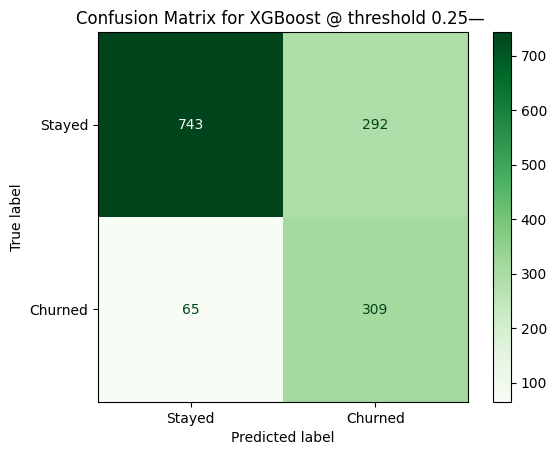

In [23]:
probs_xgb = xgb.predict_proba(X_test)[:, 1]
preds_xgb_tuned = (probs_xgb >= 0.25).astype(int)

cm_xgb_tuned = confusion_matrix(y_test, preds_xgb_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb_tuned, display_labels=['Stayed', 'Churned'])
disp.plot(cmap='Greens')
plt.title('Confusion Matrix for XGBoost @ threshold 0.25— ')
plt.savefig('../outputs/confusion_matrix_xgb_tuned.png', bbox_inches='tight')
plt.show()

#### *Observation and Insights:*
- At the default threshold of 0.50, XGBoost missed 199 real churners (false
negatives) and correctly caught 175. 
- After tuning to 0.25, **missed churners dropped dramatically to 65**, with 309 correctly identified, a 55% reduction in missed churners. 
- **False alarms increased from 118 to 292**, reflecting the precision-recall tradeoff. 
---
**In business terms, the tuned model saves significantly more revenue than it wastes on unnecessary retention offers.**

### **Saving Tuned Predictions**

In [24]:
xgb_probs = xgb.predict_proba(X_test)[:, 1]
xgb_preds_tuned = (xgb_probs >= 0.25).astype(int)

results_df = X_test.copy()
results_df['Actual_Churn'] = y_test.values
results_df['Churn_Probability'] = xgb_probs
results_df['Predicted_Churn'] = xgb_preds_tuned

results_df.to_csv('../data/xgb_predictions.csv', index=False)

print(f"Saved {len(results_df)} predictions.")
print(f"Flagged as churn risk: {xgb_preds_tuned.sum()}")

Saved 1409 predictions.
Flagged as churn risk: 601


#### **Understanding the Flagged customer count**
After applying XGBoost at threshold 0.25, the model flagged 601 out of 1,409 test customers as churn risks. 

At first glance this may seem high as it's nearly 43% of the test set. However this is a direct and deliberate consequence of the threshold decision I made during model selection.

By lowering the threshold from 0.50 to 0.25, we instructed the model to flag any customer it believes has a 25% or higher probability of churning. This casts a wider net by design, prioritising recall over precision — catching more real churners at the cost of some additional false alarms.

*Of the 601 flagged customers:*
- **309 are genuine churners correctly identified (true positives)**
- 292 are loyal customers flagged unnecessarily (false positives)

This translates directly to business value:

| | Calculation | Value |
|---|---|---|
| Revenue saved | 309 caught churners × $65/month | $20,085 |
| Retention cost | 601 offers sent × $15 | $9,015 |
| **Net value** | | **$11,070** |

*The model generates $11,070 in net retained revenue per prediction cycle — demonstrating that the wider net at threshold 0.25 is economically justified.*

A missed churner costs $65 in lost monthly revenue; an unnecessary retention offer costs $15. The asymmetry of these two errors is what makes a high flag count acceptable and the lower threshold the right business decision.

***These figures are estimates based on dataset averages and will be refined with precise calculations in the cost-benefit analysis.***

---

## **Modelling Summary**
---
Three classification models were trained and evaluated on the Telco churn
dataset: ***Logistic Regression, Random Forest, and XGBoost.***
Initial evaluation at the default 0.50 decision threshold showed Logistic Regression leading on recall (0.561), with XGBoost and Random Forest trailing at 0.524 and 0.481 respectively.

Threshold tuning was applied to all three models based on the business
priority of maximising recall based on the fact that ***a missed churner (~$65/month lost) is significantly more costly than a false alarm (~$15 retention offer).***

**Each model's optimal threshold was selected at the point where recall exceeded 0.75 without precision falling below 0.50.**

***After tuning, XGBoost at threshold 0.25 emerged as the strongest model:***
- *Recall:*0.826 — catches 83% of real churners
- *Precision:* 0.510 — correct on roughly half of all churn flags
- *F1:* 0.630 — best overall balance of the three models
- *AUC:* 0.84 — tied highest with Logistic Regression
- *Average Precision:* 0.66 — highest of all three models

Random Forest underperformed throughout, likely due to over-reliance on
correlated financial variables. **Logistic Regression remains a strong interpretable alternative, particularly if regulatory explainability is required.**

XGBoost's feature importance analysis identified Internet Service (Fiber optic), contract type, and tenure as the primary drivers of churn — findings consistent across all three models and directly actionable for retention strategy.

**The selected model (XGBoost at threshold 0.25) is carried forward into the cost-benefit analysis.**

## *Saving Model (joblib)*

In [25]:
# saving the trained XGBoost model to disk
# this means no retraining of the model every time predictions are needed
joblib.dump(xgb, '../outputs/xgb_churn_model.pkl')
print("Model saved to outputs/xgb_churn_model.pkl")

Model saved to outputs/xgb_churn_model.pkl
